# Import Libraries

In [1]:
import os
import math
import time
import random
import shutil
import itertools
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from multiprocessing import Pool, cpu_count
from tqdm import tqdm, trange

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

import brevitas.nn as qnn
from brevitas.nn import QuantLinear, QuantReLU, QuantConv2d
from brevitas.quant.binary import SignedBinaryActPerTensorConst
from brevitas.quant.binary import SignedBinaryWeightPerTensorConst
from brevitas.inject.enum import QuantType
from brevitas.quant_tensor.int_quant_tensor import IntQuantTensor
from brevitas.function.ops_ste import round_ste
from brevitas.quant import Int8WeightPerChannelFloat

# Network Definition

#### Neuron number and precision in each layer listed in this area for the MLP used in MNIST classification

In [2]:
kernel_num_CONV_layer_0_0 = 64
kernel_num_CONV_layer_0_1 = 64

kernel_num_CONV_layer_1_0 = 128
kernel_num_CONV_layer_1_1 = 128

kernel_num_CONV_layer_2_0 = 256
kernel_num_CONV_layer_2_1 = 256

neuron_num_FC_layer_0 = 512
neuron_num_FC_layer_1 = 512
neuron_num_OUT_layer  = 10

precision_CONV_layer_0_0 = 8
precision_CONV_layer_0_1 = 8

precision_CONV_layer_1_0 = 4
precision_CONV_layer_1_1 = 4

precision_CONV_layer_2_0 = 2
precision_CONV_layer_2_1 = 2

precision_FC_layer_0 = 8
precision_FC_layer_1 = 4
precision_OUT_layer  = 2

#### Hyperparameters setting here.

In [3]:
epochs = 100
batch_sizes = [128]
dropout_rates = [0.0, 0.05, 0.1]
lr_max_pool = [0.001, 0.0005]
lr_min_pool = [0.00001, 0.000001]

#### GPU selection. After decided which GPU to train, don't change it before completing the training

In [4]:
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

In [5]:
GPU_device = "cuda:1"

#### Training date output folder path, for different network model setting, please change the name of save_path

In [6]:
save_path     = "CNV_mixed_842_842bit"

project_root  = os.path.abspath(".")
dataset_root  = os.path.join(project_root, "dataset/SVHN")
train_root    = os.path.join(project_root, "train")
output_root   = os.path.join(train_root, save_path)
report_root  = os.path.join(project_root, "report")

print("Dataset Download Path: ", dataset_root, "\n")
print("Training Data Output Path: ", output_root, "\n")
print("Training Report Output Path: ", report_root)

os.makedirs(dataset_root, exist_ok=True)
os.makedirs(output_root, exist_ok=True)
os.makedirs(report_root, exist_ok=True)

Dataset Download Path:  /home/yuhao/project/QModels-Brevitas-Example/brevitas_std_qnn/classification/SVHN/perChannel/dataset/SVHN 

Training Data Output Path:  /home/yuhao/project/QModels-Brevitas-Example/brevitas_std_qnn/classification/SVHN/perChannel/train/CNV_mixed_842_842bit 

Training Report Output Path:  /home/yuhao/project/QModels-Brevitas-Example/brevitas_std_qnn/classification/SVHN/perChannel/report


#### Following are the code to complete the network definition

In [7]:
def int_range(act_bit_width):
    if (act_bit_width>1):
        min_val = -2.0**(act_bit_width-1.0)
        max_val = 2.0**(act_bit_width-1.0)-1.0
    else:
        min_val = -1.0
        max_val = 1.0
    return min_val, max_val

In [8]:
kernel_size      = (3,3) 

In [9]:
in_channel_0_0   = 3
out_channel_0_0  = kernel_num_CONV_layer_0_0 
in_channel_0_1   = kernel_num_CONV_layer_0_0
out_channel_0_1  = kernel_num_CONV_layer_0_1 

in_channel_1_0   = kernel_num_CONV_layer_0_1
out_channel_1_0  = kernel_num_CONV_layer_1_0
in_channel_1_1   = kernel_num_CONV_layer_1_0
out_channel_1_1  = kernel_num_CONV_layer_1_1 

in_channel_2_0   = kernel_num_CONV_layer_1_1
out_channel_2_0  = kernel_num_CONV_layer_2_0
in_channel_2_1   = kernel_num_CONV_layer_2_0
out_channel_2_1  = kernel_num_CONV_layer_2_1 

input_length     = 4*4*kernel_num_CONV_layer_2_1

hidden_0         = neuron_num_FC_layer_0  
hidden_1         = neuron_num_FC_layer_1

output_length    = neuron_num_OUT_layer 

In [10]:
conv_0_0_bit_width = precision_CONV_layer_0_0
conv_0_1_bit_width = precision_CONV_layer_0_1

conv_1_0_bit_width = precision_CONV_layer_1_0
conv_1_1_bit_width = precision_CONV_layer_1_1

conv_2_0_bit_width = precision_CONV_layer_2_0
conv_2_1_bit_width = precision_CONV_layer_2_1

fc_0_bit_width = precision_FC_layer_0
fc_1_bit_width = precision_FC_layer_1
out_bit_width  = precision_OUT_layer

In [11]:
min_val, max_val = int_range(conv_0_0_bit_width)

In [12]:
class CNV(nn.Module):
    def __init__(self, dropout=0.5):
        super(CNV, self).__init__()
        
        self.input_bin  = qnn.QuantIdentity(
                         quant_type='binary',
                         scaling_impl_type='stats',
                         bit_width=conv_0_0_bit_width,
                         return_quant_tensor=True)
        self.input_quan = qnn.QuantIdentity(
                         quant_type='int',
                         scaling_impl_type='stats',
                         bit_width=conv_0_0_bit_width,
                         return_quant_tensor=True)
        
        self.conv0_0_bin  = qnn.QuantConv2d(
                         in_channels=in_channel_0_0,
                         out_channels=out_channel_0_0,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1,
                         weight_bit_width=conv_0_0_bit_width,
                         weight_quant_type=QuantType.BINARY,
                         weight_scaling_per_output_channel=True,
                         bias=False)
        self.conv0_0_quan = qnn.QuantConv2d(
                         in_channels=in_channel_0_0,
                         out_channels=out_channel_0_0,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1,
                         weight_bit_width=conv_0_0_bit_width,
                         weight_quant=Int8WeightPerChannelFloat,
                         bias=False)
        self.bn0_0   = nn.BatchNorm2d(out_channel_0_0)
        self.act0_0  = qnn.QuantReLU(
                         bit_width=conv_0_1_bit_width, 
                         return_quant_tensor=True)
        self.drop0_0 = nn.Dropout2d(dropout)
        
        self.conv0_1_bin  = qnn.QuantConv2d( 
                         in_channels=in_channel_0_1,
                         out_channels=out_channel_0_1,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1,
                         weight_bit_width=conv_0_1_bit_width,
                         weight_quant_type=QuantType.BINARY,
                         weight_scaling_per_output_channel=True,
                         bias=False)
        self.conv0_1_quan = qnn.QuantConv2d( 
                         in_channels=in_channel_0_1,
                         out_channels=out_channel_0_1,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1,
                         weight_bit_width=conv_0_1_bit_width,
                         weight_quant=Int8WeightPerChannelFloat,
                         bias=False)
        self.bn0_1   = nn.BatchNorm2d(out_channel_0_1)
        self.act0_1  = qnn.QuantReLU(
                         bit_width=conv_1_0_bit_width, 
                         return_quant_tensor=True)
        self.drop0_1 = nn.Dropout2d(dropout)
        
        self.pool0 = nn.MaxPool2d(2)
        
        self.conv1_0_bin  = qnn.QuantConv2d( 
                         in_channels=in_channel_1_0,
                         out_channels=out_channel_1_0,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1,
                         weight_bit_width=conv_1_0_bit_width,
                         weight_quant_type=QuantType.BINARY,
                         weight_scaling_per_output_channel=True,
                         bias=False, 
                         return_quant_tensor=True)
        self.conv1_0_quan = qnn.QuantConv2d( 
                         in_channels=in_channel_1_0,
                         out_channels=out_channel_1_0,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1,
                         weight_bit_width=conv_1_0_bit_width,
                         weight_quant=Int8WeightPerChannelFloat,
                         bias=False, 
                         return_quant_tensor=True)
        self.bn1_0   = nn.BatchNorm2d(out_channel_1_0)
        self.act1_0  = qnn.QuantReLU(
                         bit_width=conv_1_1_bit_width, 
                         return_quant_tensor=True)
        self.drop1_0 = nn.Dropout2d(dropout)
        
        self.conv1_1_bin  = qnn.QuantConv2d( 
                         in_channels=in_channel_1_1,
                         out_channels=out_channel_1_1,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1,
                         weight_bit_width=conv_1_1_bit_width,
                         weight_quant_type=QuantType.BINARY,
                         weight_scaling_per_output_channel=True,
                         bias=False, 
                         return_quant_tensor=True)
        self.conv1_1_quan = qnn.QuantConv2d( 
                         in_channels=in_channel_1_1,
                         out_channels=out_channel_1_1,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1,
                         weight_bit_width=conv_1_1_bit_width,
                         weight_quant=Int8WeightPerChannelFloat,
                         bias=False, 
                         return_quant_tensor=True)
        self.bn1_1   = nn.BatchNorm2d(out_channel_1_1)
        self.act1_1  = qnn.QuantReLU(
                         bit_width=conv_2_0_bit_width, 
                         return_quant_tensor=True)
        self.drop1_1 = nn.Dropout2d(dropout)
        
        self.pool1 = nn.MaxPool2d(2)
        
        self.conv2_0_bin  = qnn.QuantConv2d( 
                         in_channels=in_channel_2_0,
                         out_channels=out_channel_2_0,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1,
                         weight_bit_width=conv_2_0_bit_width,
                         weight_quant_type=QuantType.BINARY,
                         weight_scaling_per_output_channel=True,
                         bias=False, 
                         return_quant_tensor=True)
        self.conv2_0_quan = qnn.QuantConv2d( 
                         in_channels=in_channel_2_0,
                         out_channels=out_channel_2_0,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1,
                         weight_bit_width=conv_2_0_bit_width,
                         weight_quant=Int8WeightPerChannelFloat,
                         bias=False, 
                         return_quant_tensor=True)
        self.bn2_0   = nn.BatchNorm2d(out_channel_2_0)
        self.act2_0  = qnn.QuantReLU(
                         bit_width=conv_2_1_bit_width, 
                         return_quant_tensor=True)
        self.drop2_0 = nn.Dropout2d(dropout)
        
        self.conv2_1_bin  = qnn.QuantConv2d( 
                         in_channels=in_channel_2_1,
                         out_channels=out_channel_2_1,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1,
                         weight_bit_width=conv_2_1_bit_width,
                         weight_quant_type=QuantType.BINARY,
                         weight_scaling_per_output_channel=True,
                         bias=False, 
                         return_quant_tensor=True)
        self.conv2_1_quan = qnn.QuantConv2d( 
                         in_channels=in_channel_2_1,
                         out_channels=out_channel_2_1,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1,
                         weight_bit_width=conv_2_1_bit_width,
                         weight_quant=Int8WeightPerChannelFloat,
                         bias=False, 
                         return_quant_tensor=True)
        self.bn2_1   = nn.BatchNorm2d(out_channel_2_1)
        self.act2_1  = qnn.QuantReLU(
                         bit_width=fc_0_bit_width, 
                         return_quant_tensor=True)
        self.drop2_1 = nn.Dropout2d(dropout)
        
        self.pool2 = nn.MaxPool2d(2)
        
        self.fc3_bin  = qnn.QuantLinear(
                         input_length, 
                         hidden_0, 
                         weight_bit_width=fc_0_bit_width,
                         weight_quant_type=QuantType.BINARY,
                         weight_scaling_per_output_channel=True,
                         bias=False)
        self.fc3_quan  = qnn.QuantLinear(
                         input_length, 
                         hidden_0, 
                         weight_bit_width=fc_0_bit_width,
                         weight_quant=Int8WeightPerChannelFloat,
                         bias=False)
        self.bn3   = nn.BatchNorm1d(hidden_0)
        self.act3  = qnn.QuantReLU(
                         bit_width=fc_1_bit_width, 
                         return_quant_tensor=True)
        self.drop3 = nn.Dropout(dropout)
        
        self.fc4_bin  = qnn.QuantLinear(
                         hidden_0, 
                         hidden_1, 
                         weight_bit_width=fc_1_bit_width,
                         weight_quant_type=QuantType.BINARY,
                         weight_scaling_per_output_channel=True,
                         bias=False, 
                         return_quant_tensor=True)
        self.fc4_quan = qnn.QuantLinear(
                         hidden_0, 
                         hidden_1, 
                         weight_bit_width=fc_1_bit_width,
                         weight_quant=Int8WeightPerChannelFloat,
                         bias=False, 
                         return_quant_tensor=True)
        self.bn4   = nn.BatchNorm1d(hidden_1)
        self.act4  = qnn.QuantReLU(
                         bit_width=out_bit_width, 
                         return_quant_tensor=True)
        self.drop4 = nn.Dropout(dropout)
        
        self.out_bin  = qnn.QuantLinear(
                         hidden_1, 
                         output_length, 
                         weight_bit_width=out_bit_width,
                         weight_quant_type=QuantType.BINARY,
                         weight_scaling_per_output_channel=True,
                         bias=False)
        self.out_quan = qnn.QuantLinear(
                         hidden_1, 
                         output_length, 
                         weight_bit_width=out_bit_width,
                         weight_quant=Int8WeightPerChannelFloat,
                         bias=False)

    def forward(self, x):

        if conv_0_0_bit_width==1:
            out = self.input_bin(x)
        else:
            out = self.input_quan(x)
        
        if conv_0_0_bit_width==1:
            out = self.drop0_0(self.act0_0(self.bn0_0(self.conv0_0_bin(out))))
        else:
            out = self.drop0_0(self.act0_0(self.bn0_0(self.conv0_0_quan(out))))
            
        if conv_0_1_bit_width==1:
            out = self.drop0_1(self.act0_1(self.bn0_1(self.conv0_1_bin(out))))
        else:
            out = self.drop0_1(self.act0_1(self.bn0_1(self.conv0_1_quan(out))))
            
        out = self.pool0(out)
        
        if conv_1_0_bit_width==1:
            out = self.drop1_0(self.act1_0(self.bn1_0(self.conv1_0_bin(out))))
        else:
            out = self.drop1_0(self.act1_0(self.bn1_0(self.conv1_0_quan(out))))
            
        if conv_1_1_bit_width==1:
            out = self.drop1_1(self.act1_1(self.bn1_1(self.conv1_1_bin(out))))
        else:
            out = self.drop1_1(self.act1_1(self.bn1_1(self.conv1_1_quan(out))))
        
        out = self.pool1(out)
        
        if conv_2_0_bit_width==1:
            out = self.drop2_0(self.act2_0(self.bn2_0(self.conv2_0_bin(out))))
        else:
            out = self.drop2_0(self.act2_0(self.bn2_0(self.conv2_0_quan(out))))
            
        if conv_2_1_bit_width==1:
            out = self.drop2_1(self.act2_1(self.bn2_1(self.conv2_1_bin(out))))
        else:
            out = self.drop2_1(self.act2_1(self.bn2_1(self.conv2_1_quan(out))))
        
        out = self.pool2(out)
        
        out = out.reshape(out.shape[0], -1)

        if fc_0_bit_width==1:
            out = self.drop3(self.act3(self.bn3(self.fc3_bin(out))))
        else:
            out = self.drop3(self.act3(self.bn3(self.fc3_quan(out))))
        
        if fc_1_bit_width==1:
            out = self.drop4(self.act4(self.bn4(self.fc4_bin(out))))
        else:
            out = self.drop4(self.act4(self.bn4(self.fc4_quan(out))))

        if out_bit_width==1:
            out = self.out_bin(out)
        else:
            out = self.out_quan(out)
        
        return out

# Random Seed Utility

In [13]:
def set_random_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

# Define Dataloader

In [14]:
test_batch_size = 4096

In [15]:
def get_dataloaders(batch_size):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            (0.5, 0.5, 0.5),   # mean for SVHN RGB
            (0.5, 0.5, 0.5)    # std for SVHN RGB
        )
    ])

    train_dataset = datasets.SVHN(
        dataset_root,
        split="train",
        download=True,
        transform=transform
    )

    test_dataset = datasets.SVHN(
        dataset_root,
        split="test",
        download=True,
        transform=transform
    )

    val_size = int(0.2 * len(train_dataset))
    train_size = len(train_dataset) - val_size
    train_set, val_set = random_split(train_dataset, [train_size, val_size])

    return (
        DataLoader(
            train_set,
            batch_size=batch_size,
            shuffle=True,
            num_workers=6,
            pin_memory=True,
            persistent_workers=True,
            prefetch_factor=4,
        ),
        DataLoader(
            val_set,
            batch_size=batch_size,
            shuffle=False,
            num_workers=6,
            pin_memory=True,
            persistent_workers=True,
            prefetch_factor=4,
        ),
        DataLoader(
            test_dataset,
            batch_size=test_batch_size,
            shuffle=False,
            num_workers=6,
            pin_memory=True,
            persistent_workers=True,
            prefetch_factor=4,
        ),
    )

# Evaluation Pipeline

In [16]:
def evaluate(model, criterion, device, loader, train):
    model.eval()
    loss_total, correct, total = 0, 0, 0
    with torch.no_grad():
        if (train):
            for x, y in loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                loss_total += loss.item() * x.size(0)
                _, pred = out.max(1)
                correct += (pred == y).sum().item()
                total += x.size(0)
        else:
            for x, y in tqdm(loader, desc="Evaluation", leave=True):
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                loss_total += loss.item() * x.size(0)
                _, pred = out.max(1)
                correct += (pred == y).sum().item()
                total += x.size(0)
    return loss_total / total, correct / total

# Plot Training Loss and Accuracy

In [17]:
def plot_train(history, save_dir):
    # Plot and show
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.legend()
    plt.title("Loss")

    plt.subplot(1, 2, 2)
    plt.plot(history["train_acc"], label="Train Acc")
    plt.plot(history["val_acc"], label="Val Acc")
    plt.legend()
    plt.title("Accuracy")
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "training_plot.png"))
    plt.show()

# Training, Validation, and Testing Pipeline

In [18]:
def train_validate_test(config, save_dir):
    set_random_seed()
    os.makedirs(save_dir, exist_ok=True)
    log_file = os.path.join(save_dir, "training_log.txt")
    resume_path = os.path.join(save_dir, "checkpoint.pth")
    csv_log_path = os.path.join(save_dir, "training_log.csv")
    with open(csv_log_path, "a") as f:
        if os.path.getsize(csv_log_path) == 0:
            f.write("Epoch,Learning Rate,Train Loss,Train Acc,Val Loss,Val Acc,Epoch Time,Train Time,Val Time\n")

    epochs, batch_size, lr_max, lr_min, dropout = config
    train_loader, val_loader, test_loader = get_dataloaders(batch_size)
    device = torch.device(GPU_device if torch.cuda.is_available() else "cpu")
    model = CNV(dropout=dropout).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr_max)

    start_epoch = 0
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "epoch_time": [], "train_time": [], "val_time": []}

    if os.path.exists(resume_path):
        ckpt = torch.load(resume_path)
        model.load_state_dict(ckpt["model_state"])
        model.to(device)
        optimizer.load_state_dict(ckpt["optimizer_state"])
        history = ckpt["history"]
        start_epoch = ckpt["epoch"] + 1
        print(f"🔄 Resuming from epoch {start_epoch}")
    else:
        with open(log_file, "w") as f:
            f.write("Training started\n")

    # Training Loop
    t = trange(start_epoch, epochs, desc="Training", leave=True)
    for epoch in t:
        epoch_start = time.time()
        model.train()
        lr = lr_min + 0.5 * (lr_max - lr_min) * (1 + math.cos(math.pi * epoch / epochs))
        for g in optimizer.param_groups:
            g["lr"] = lr

        train_start = time.time()
        train_loss, correct, total = 0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * x.size(0)
            _, pred = out.max(1)
            correct += (pred == y).sum().item()
            total += x.size(0)
        train_time = time.time() - train_start

        val_start = time.time()
        val_loss, val_acc = evaluate(model, criterion, device, val_loader, train=True)
        val_time = time.time() - val_start
        train_loss /= total
        train_acc = correct / total
        epoch_time = time.time() - epoch_start
        
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["epoch_time"].append(epoch_time/60)
        history["train_time"].append(train_time/60)
        history["val_time"].append(val_time/60)

        log_line = (f"Epoch {epoch+1}/{epochs} - LR: {lr:.6f} | "
                    f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
                    f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f} | "
                    f"Epoch Time: {epoch_time/60:.2f}, Train Time: {train_time/60:.2f}, Val Time: {val_time/60:.2f}")
        
        with open(log_file, "a") as f:
            f.write(log_line + "\n")

        
        with open(os.path.join(save_dir, "training_log.csv"), "a") as f:
            f.write(f"{epoch+1},{lr:.6f},{train_loss:.4f},{train_acc:.4f},{val_loss:.4f},{val_acc:.4f},{epoch_time/60:.4f},{train_time/60:.4f},{val_time/60:.4f}\n")

        t.set_description("| LR: %.6f | Train Acc: %.4f | Val Acc: %.4f | Epoch Time: %.2f | " % (lr, train_acc, val_acc, epoch_time/60))
        t.refresh()

        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "history": history
        }, resume_path)

    # Plot and show the training history
    plot_train(history, save_dir)

    # Test the original trained model
    original_test_loss, original_test_acc = evaluate(model, criterion, device, test_loader, train=False)
    final_line = f"Original Model Final Test Loss: {original_test_loss:.4f} Accuracy: {original_test_acc:.4f}"
    print(final_line)
    with open(log_file, "a") as f:
        f.write("Training completed\n")
        f.write(final_line + "\n")

    # Save the trained model
    torch.save(model.state_dict(), os.path.join(save_dir, "final_model.pth"))
    with open(log_file, "a") as f:
        f.write(final_line + "\n")
    print("\n")

    return original_test_acc, resume_path

# Hyperparameter Searching for Network Training and Testing

In [19]:
def Hyperparameter_searching(epochs, batch_sizes, lr_max_pool, lr_min_pool, dropout_rates):
    
    epochs = epochs
    batch_sizes = batch_sizes
    lr_max_pool = lr_max_pool
    lr_min_pool = lr_min_pool
    
    all_runs = [
        f"batch{bs}_lr_max_{lr_max}_min_{lr_min}"
        for bs, lr_max, lr_min in itertools.product(batch_sizes, lr_max_pool, lr_min_pool)
    ]
    
    completed_runs = []
    for run in all_runs:
        log_path = os.path.join(output_root, run, "training_log.txt")
        if os.path.exists(log_path):
            with open(log_path, "r") as f:
                if any("Training completed" in line for line in f):
                    completed_runs.append(run)
    
    if len(completed_runs) == len(all_runs):
        print("✅ All combinations completed. Restarting from scratch...")
        for run in all_runs:
            shutil.rmtree(os.path.join(output_root, run), ignore_errors=True)
        if os.path.exists(os.path.join(report_root, save_path+"_report.csv")):
            os.remove(os.path.join(report_root, save_path+"_report.csv"))
        completed_runs = []
    
    results = []
    for batch_size, lr_max, lr_min, dropout in itertools.product(batch_sizes, lr_max_pool, lr_min_pool, dropout_rates):
        run_name = f"batch{batch_size}_lr_max_{lr_max}_min_{lr_min}_dp{dropout}"
        save_dir = os.path.join(output_root, run_name)
    
        if run_name in completed_runs:
            print(f"✅ Skipping {run_name}")
            with open(os.path.join(save_dir, "training_log.txt")) as f:
                for line in f:
                    if "Final Test Loss" in line:
                        acc = float(line.strip().split()[-1])
                        results.append((run_name, acc))
            continue
    
        print(f"🚀 Running: {run_name}")
        acc, resume_path = train_validate_test([epochs, batch_size, lr_max, lr_min, dropout], save_dir)
        results.append((run_name, acc, epochs, batch_size, lr_max, lr_min, dropout, resume_path))
    
    results.sort(key=lambda x: x[1], reverse=True)
    best_config, best_acc, best_epochs, best_batch_size, best_lr_max, best_lr_min, best_dropout, best_resume_path = results[0]
    
    with open(os.path.join(report_root, save_path+"_report.csv"), "w") as f:
        f.write("Epoch,Batch Size,LR_max,LR_min,Dropout,Accuracy\n")
        for name, acc, epoch, batch_size, lr_max, lr_min, dropout, resume_path in results:
            f.write(f"{epoch},{batch_size},{lr_max:.4f},{lr_min:.6f},{dropout:.4f},{acc:.4f}\n")
            
    return best_epochs, best_batch_size, best_lr_max, best_lr_min, best_dropout, best_resume_path

In [20]:
def best_evaluation(epochs, batch_size, lr_max, lr_min, dropout, resume_path):
    set_random_seed()

    epochs, batch_size, lr_max, lr_min, dropout = epochs, batch_size, lr_max, lr_min, dropout
    train_loader, val_loader, test_loader = get_dataloaders(batch_size)
    device = torch.device(GPU_device if torch.cuda.is_available() else "cpu")
    model = CNV(dropout=dropout).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr_max)

    if os.path.exists(resume_path):
        ckpt = torch.load(resume_path)
        model.load_state_dict(ckpt["model_state"])
        model.to(device)
        optimizer.load_state_dict(ckpt["optimizer_state"])
        history = ckpt["history"]
        print("Best model loaded.")
    else:
        print("Best model lost.")

    # Test the original trained model
    original_test_loss, original_test_acc = evaluate(model, criterion, device, test_loader, train=False)
    final_line = (
        f"Best Original Model Final Test Loss: {original_test_loss:.4f} "
        f"Acc: {original_test_acc:.4f} "
    )
    print(final_line)
    print("\n")

    with open(os.path.join(report_root, save_path + "_best_eval.csv"), "w") as f:
        f.write("Epoch,Batch Size,LR_max,LR_min,Dropout,Acc,Loss\n")
        f.write(f"{epochs},{batch_size},{lr_max:.4f},{lr_min:.6f},{dropout:.4f},{original_test_acc:.4f},{original_test_loss:.4f}\n")

🚀 Running: batch128_lr_max_0.001_min_1e-05_dp0.0


Using downloaded and verified file: /home/yuhao/project/QModels-Brevitas-Example/brevitas_std_qnn/classification/SVHN/perChannel/dataset/SVHN/train_32x32.mat


Using downloaded and verified file: /home/yuhao/project/QModels-Brevitas-Example/brevitas_std_qnn/classification/SVHN/perChannel/dataset/SVHN/test_32x32.mat


🔄 Resuming from epoch 5


Training:   0%|                                                                                                                                                                                                                 | 0/95 [00:00<?, ?it/s]

...

| LR: 0.000011 | Train Acc: 1.0000 | Val Acc: 0.9463 | Epoch Time: 0.25 | :  99%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌ | 94/95 [23:50<00:15, 15.22s/it]

| LR: 0.000010 | Train Acc: 1.0000 | Val Acc: 0.9459 | Epoch Time: 0.25 | :  99%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌ | 94/95 [24:05<00:15, 15.22s/it]

| LR: 0.000010 | Train Acc: 1.0000 | Val Acc: 0.9459 | Epoch Time: 0.25 | :  99%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌ | 94/95 [24:05<00:15, 15.22s/it]

| LR: 0.000010 | Train Acc: 1.0000 | Val Acc: 0.9459 | Epoch Time: 0.25 | : 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 95/95 [24:05<00:00, 15.20s/it]

| LR: 0.000010 | Train Acc: 1.0000 | Val Acc: 0.9459 | Epoch Time: 0.25 | : 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 95/95 [24:05<00:00, 15.22s/it]

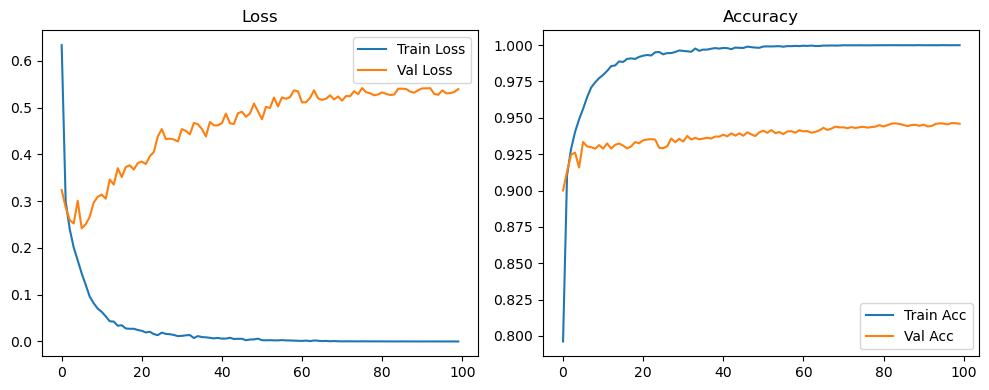

Evaluation:   0%|                                                                                                                                                                                                                | 0/7 [00:00<?, ?it/s]

Evaluation:  14%|████████████████████████████▌                                                                                                                                                                           | 1/7 [00:01<00:08,  1.38s/it]

Evaluation:  29%|█████████████████████████████████████████████████████████▏                                                                                                                                              | 2/7 [00:01<00:03,  1.48it/s]

Evaluation:  43%|█████████████████████████████████████████████████████████████████████████████████████▋                                                                                                                  | 3/7 [00:01<00:01,  2.21it/s]

Evaluation:  57%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                                                                     | 4/7 [00:01<00:01,  2.88it/s]

...

| LR: 0.000011 | Train Acc: 0.9999 | Val Acc: 0.9469 | Epoch Time: 0.26 | :  99%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋ | 99/100 [26:33<00:15, 15.55s/it]

| LR: 0.000010 | Train Acc: 0.9999 | Val Acc: 0.9474 | Epoch Time: 0.26 | :  99%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋ | 99/100 [26:48<00:15, 15.55s/it]

| LR: 0.000010 | Train Acc: 0.9999 | Val Acc: 0.9474 | Epoch Time: 0.26 | :  99%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋ | 99/100 [26:48<00:15, 15.55s/it]

| LR: 0.000010 | Train Acc: 0.9999 | Val Acc: 0.9474 | Epoch Time: 0.26 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [26:48<00:00, 15.50s/it]

| LR: 0.000010 | Train Acc: 0.9999 | Val Acc: 0.9474 | Epoch Time: 0.26 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [26:48<00:00, 16.09s/it]

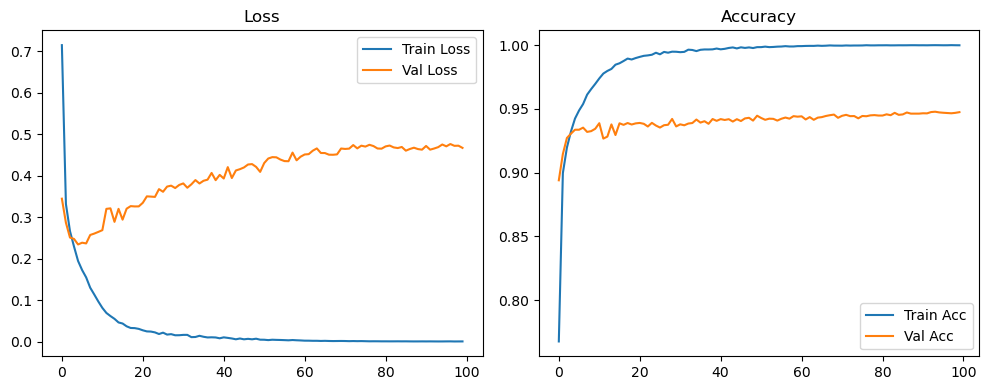

Evaluation:   0%|                                                                                                                                                                                                                | 0/7 [00:00<?, ?it/s]

Evaluation:  14%|████████████████████████████▌                                                                                                                                                                           | 1/7 [00:01<00:07,  1.24s/it]

Evaluation:  29%|█████████████████████████████████████████████████████████▏                                                                                                                                              | 2/7 [00:01<00:03,  1.61it/s]

Evaluation:  43%|█████████████████████████████████████████████████████████████████████████████████████▋                                                                                                                  | 3/7 [00:01<00:01,  2.37it/s]

Evaluation:  57%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                                                                     | 4/7 [00:01<00:00,  3.04it/s]

...

| LR: 0.000011 | Train Acc: 0.9998 | Val Acc: 0.9467 | Epoch Time: 0.26 | :  99%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋ | 99/100 [26:36<00:15, 15.59s/it]

| LR: 0.000010 | Train Acc: 0.9998 | Val Acc: 0.9476 | Epoch Time: 0.26 | :  99%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋ | 99/100 [26:51<00:15, 15.59s/it]

| LR: 0.000010 | Train Acc: 0.9998 | Val Acc: 0.9476 | Epoch Time: 0.26 | :  99%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋ | 99/100 [26:51<00:15, 15.59s/it]

| LR: 0.000010 | Train Acc: 0.9998 | Val Acc: 0.9476 | Epoch Time: 0.26 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [26:51<00:00, 15.57s/it]

| LR: 0.000010 | Train Acc: 0.9998 | Val Acc: 0.9476 | Epoch Time: 0.26 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [26:51<00:00, 16.12s/it]

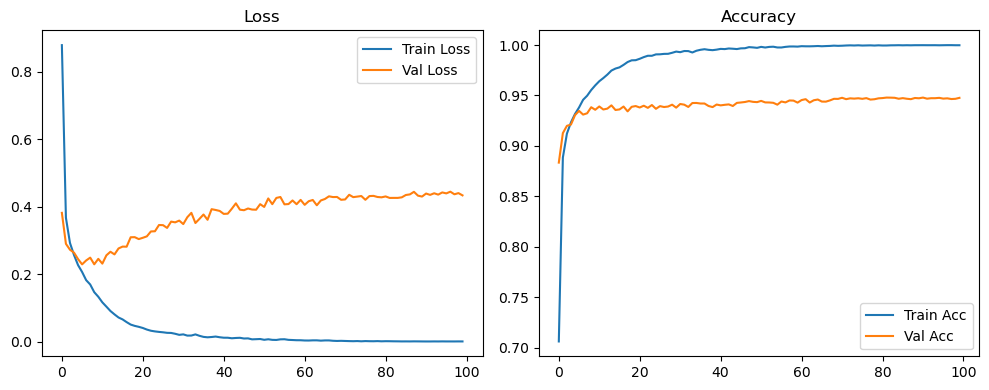

Evaluation:   0%|                                                                                                                                                                                                                | 0/7 [00:00<?, ?it/s]

Evaluation:  14%|████████████████████████████▌                                                                                                                                                                           | 1/7 [00:01<00:07,  1.22s/it]

Evaluation:  29%|█████████████████████████████████████████████████████████▏                                                                                                                                              | 2/7 [00:01<00:03,  1.63it/s]

Evaluation:  43%|█████████████████████████████████████████████████████████████████████████████████████▋                                                                                                                  | 3/7 [00:01<00:01,  2.39it/s]

Evaluation:  57%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                                                                     | 4/7 [00:01<00:00,  3.06it/s]

...

| LR: 0.000002 | Train Acc: 1.0000 | Val Acc: 0.9443 | Epoch Time: 0.26 | :  99%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋ | 99/100 [26:00<00:15, 15.31s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9451 | Epoch Time: 0.25 | :  99%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋ | 99/100 [26:15<00:15, 15.31s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9451 | Epoch Time: 0.25 | :  99%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋ | 99/100 [26:15<00:15, 15.31s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9451 | Epoch Time: 0.25 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [26:15<00:00, 15.32s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9451 | Epoch Time: 0.25 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [26:15<00:00, 15.76s/it]

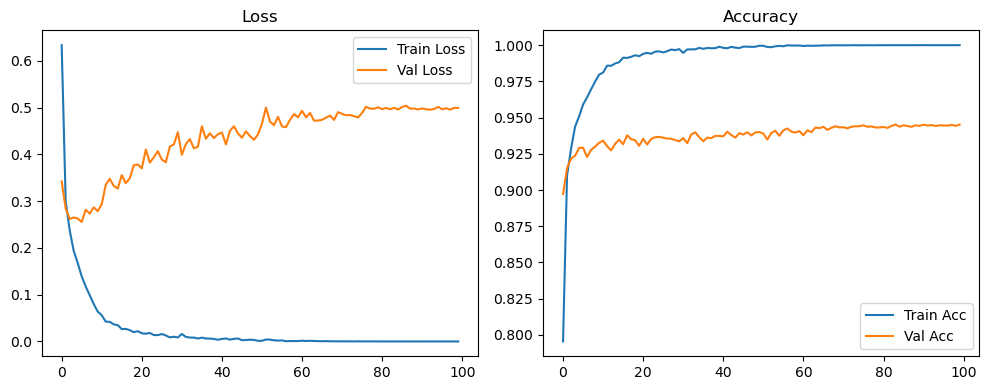

Evaluation:   0%|                                                                                                                                                                                                                | 0/7 [00:00<?, ?it/s]

Evaluation:  14%|████████████████████████████▌                                                                                                                                                                           | 1/7 [00:01<00:08,  1.44s/it]

Evaluation:  29%|█████████████████████████████████████████████████████████▏                                                                                                                                              | 2/7 [00:01<00:03,  1.42it/s]

Evaluation:  43%|█████████████████████████████████████████████████████████████████████████████████████▋                                                                                                                  | 3/7 [00:01<00:01,  2.14it/s]

Evaluation:  57%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                                                                     | 4/7 [00:02<00:01,  2.80it/s]

...

| LR: 0.000002 | Train Acc: 1.0000 | Val Acc: 0.9450 | Epoch Time: 0.26 | :  99%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋ | 99/100 [26:33<00:15, 15.74s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9454 | Epoch Time: 0.26 | :  99%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋ | 99/100 [26:48<00:15, 15.74s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9454 | Epoch Time: 0.26 | :  99%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋ | 99/100 [26:48<00:15, 15.74s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9454 | Epoch Time: 0.26 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [26:48<00:00, 15.77s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9454 | Epoch Time: 0.26 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [26:48<00:00, 16.09s/it]

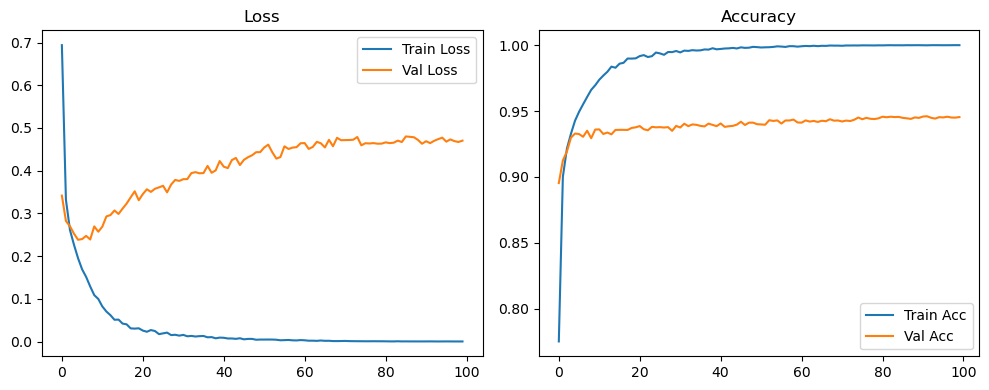

Evaluation:   0%|                                                                                                                                                                                                                | 0/7 [00:00<?, ?it/s]

Evaluation:  14%|████████████████████████████▌                                                                                                                                                                           | 1/7 [00:01<00:07,  1.22s/it]

Evaluation:  29%|█████████████████████████████████████████████████████████▏                                                                                                                                              | 2/7 [00:01<00:03,  1.63it/s]

Evaluation:  43%|█████████████████████████████████████████████████████████████████████████████████████▋                                                                                                                  | 3/7 [00:01<00:01,  2.39it/s]

Evaluation:  57%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                                                                     | 4/7 [00:01<00:00,  3.06it/s]

...

| LR: 0.000002 | Train Acc: 0.9998 | Val Acc: 0.9482 | Epoch Time: 0.26 | :  99%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋ | 99/100 [26:37<00:15, 15.60s/it]

| LR: 0.000001 | Train Acc: 0.9998 | Val Acc: 0.9481 | Epoch Time: 0.26 | :  99%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋ | 99/100 [26:52<00:15, 15.60s/it]

| LR: 0.000001 | Train Acc: 0.9998 | Val Acc: 0.9481 | Epoch Time: 0.26 | :  99%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋ | 99/100 [26:52<00:15, 15.60s/it]

| LR: 0.000001 | Train Acc: 0.9998 | Val Acc: 0.9481 | Epoch Time: 0.26 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [26:52<00:00, 15.59s/it]

| LR: 0.000001 | Train Acc: 0.9998 | Val Acc: 0.9481 | Epoch Time: 0.26 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [26:52<00:00, 16.13s/it]

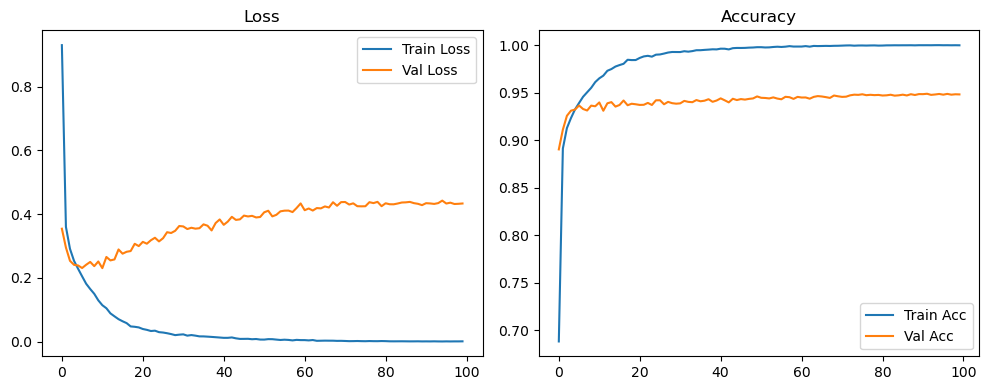

Evaluation:   0%|                                                                                                                                                                                                                | 0/7 [00:00<?, ?it/s]

Evaluation:  14%|████████████████████████████▌                                                                                                                                                                           | 1/7 [00:01<00:07,  1.26s/it]

Evaluation:  29%|█████████████████████████████████████████████████████████▏                                                                                                                                              | 2/7 [00:01<00:03,  1.59it/s]

Evaluation:  43%|█████████████████████████████████████████████████████████████████████████████████████▋                                                                                                                  | 3/7 [00:01<00:01,  2.34it/s]

Evaluation:  57%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                                                                     | 4/7 [00:01<00:00,  3.02it/s]

...

| LR: 0.000010 | Train Acc: 0.9999 | Val Acc: 0.9439 | Epoch Time: 0.25 | :  99%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋ | 99/100 [26:01<00:15, 15.27s/it]

| LR: 0.000010 | Train Acc: 0.9999 | Val Acc: 0.9445 | Epoch Time: 0.25 | :  99%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋ | 99/100 [26:16<00:15, 15.27s/it]

| LR: 0.000010 | Train Acc: 0.9999 | Val Acc: 0.9445 | Epoch Time: 0.25 | :  99%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋ | 99/100 [26:16<00:15, 15.27s/it]

| LR: 0.000010 | Train Acc: 0.9999 | Val Acc: 0.9445 | Epoch Time: 0.25 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [26:17<00:00, 15.25s/it]

| LR: 0.000010 | Train Acc: 0.9999 | Val Acc: 0.9445 | Epoch Time: 0.25 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [26:17<00:00, 15.77s/it]

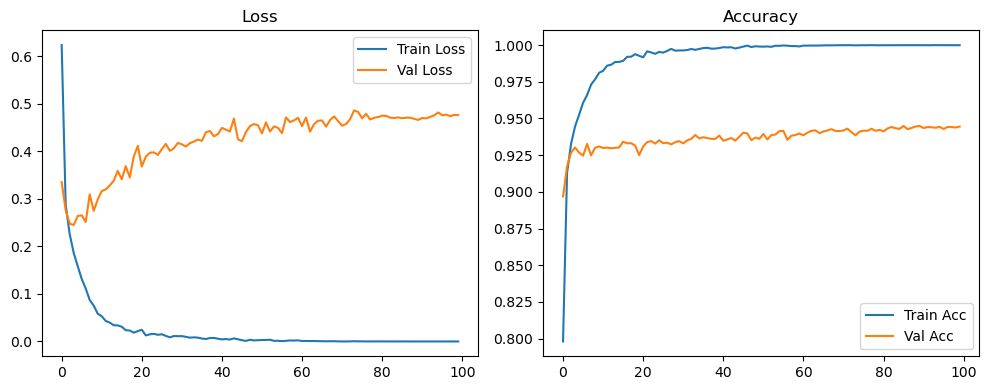

Evaluation:   0%|                                                                                                                                                                                                                | 0/7 [00:00<?, ?it/s]

Evaluation:  14%|████████████████████████████▌                                                                                                                                                                           | 1/7 [00:01<00:07,  1.24s/it]

Evaluation:  29%|█████████████████████████████████████████████████████████▏                                                                                                                                              | 2/7 [00:01<00:03,  1.61it/s]

Evaluation:  43%|█████████████████████████████████████████████████████████████████████████████████████▋                                                                                                                  | 3/7 [00:01<00:01,  2.37it/s]

Evaluation:  57%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                                                                     | 4/7 [00:01<00:00,  3.04it/s]

...

| LR: 0.000010 | Train Acc: 1.0000 | Val Acc: 0.9482 | Epoch Time: 0.26 | :  99%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋ | 99/100 [26:31<00:15, 15.67s/it]

| LR: 0.000010 | Train Acc: 0.9999 | Val Acc: 0.9470 | Epoch Time: 0.26 | :  99%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋ | 99/100 [26:46<00:15, 15.67s/it]

| LR: 0.000010 | Train Acc: 0.9999 | Val Acc: 0.9470 | Epoch Time: 0.26 | :  99%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋ | 99/100 [26:46<00:15, 15.67s/it]

| LR: 0.000010 | Train Acc: 0.9999 | Val Acc: 0.9470 | Epoch Time: 0.26 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [26:46<00:00, 15.65s/it]

| LR: 0.000010 | Train Acc: 0.9999 | Val Acc: 0.9470 | Epoch Time: 0.26 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [26:46<00:00, 16.07s/it]

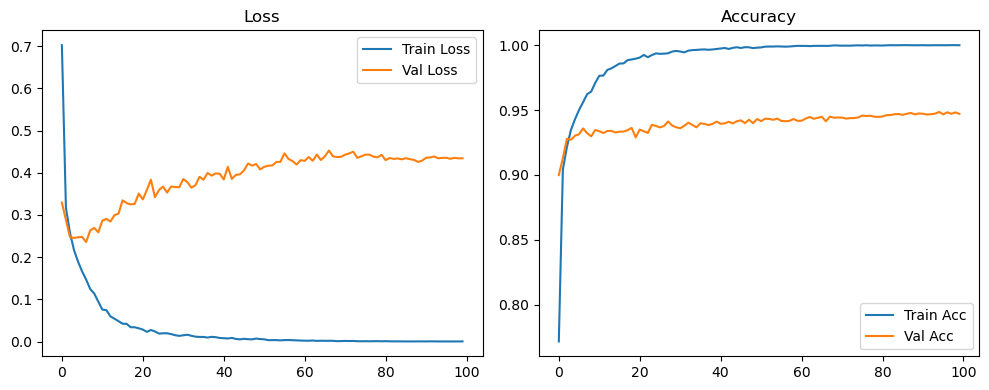

Evaluation:   0%|                                                                                                                                                                                                                | 0/7 [00:00<?, ?it/s]

Evaluation:  14%|████████████████████████████▌                                                                                                                                                                           | 1/7 [00:01<00:07,  1.33s/it]

Evaluation:  29%|█████████████████████████████████████████████████████████▏                                                                                                                                              | 2/7 [00:01<00:03,  1.52it/s]

Evaluation:  43%|█████████████████████████████████████████████████████████████████████████████████████▋                                                                                                                  | 3/7 [00:01<00:01,  2.26it/s]

Evaluation:  57%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                                                                     | 4/7 [00:01<00:01,  2.93it/s]

...

| LR: 0.000010 | Train Acc: 0.9998 | Val Acc: 0.9485 | Epoch Time: 0.27 | :  99%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋ | 99/100 [28:10<00:16, 16.59s/it]

| LR: 0.000010 | Train Acc: 0.9999 | Val Acc: 0.9472 | Epoch Time: 0.28 | :  99%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋ | 99/100 [28:27<00:16, 16.59s/it]

| LR: 0.000010 | Train Acc: 0.9999 | Val Acc: 0.9472 | Epoch Time: 0.28 | :  99%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋ | 99/100 [28:27<00:16, 16.59s/it]

| LR: 0.000010 | Train Acc: 0.9999 | Val Acc: 0.9472 | Epoch Time: 0.28 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [28:27<00:00, 16.65s/it]

| LR: 0.000010 | Train Acc: 0.9999 | Val Acc: 0.9472 | Epoch Time: 0.28 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [28:27<00:00, 17.07s/it]

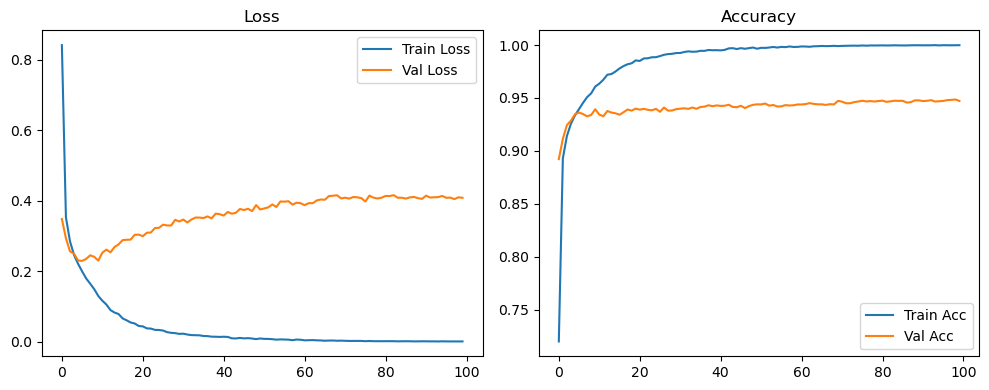

Evaluation:   0%|                                                                                                                                                                                                                | 0/7 [00:00<?, ?it/s]

Evaluation:  14%|████████████████████████████▌                                                                                                                                                                           | 1/7 [00:01<00:10,  1.83s/it]

Evaluation:  29%|█████████████████████████████████████████████████████████▏                                                                                                                                              | 2/7 [00:02<00:04,  1.16it/s]

Evaluation:  43%|█████████████████████████████████████████████████████████████████████████████████████▋                                                                                                                  | 3/7 [00:02<00:02,  1.80it/s]

Evaluation:  57%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                                                                     | 4/7 [00:02<00:01,  2.44it/s]

...

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9454 | Epoch Time: 0.26 | :  99%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋ | 99/100 [27:05<00:15, 15.52s/it]

| LR: 0.000001 | Train Acc: 0.9999 | Val Acc: 0.9446 | Epoch Time: 0.26 | :  99%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋ | 99/100 [27:20<00:15, 15.52s/it]

| LR: 0.000001 | Train Acc: 0.9999 | Val Acc: 0.9446 | Epoch Time: 0.26 | :  99%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋ | 99/100 [27:20<00:15, 15.52s/it]

| LR: 0.000001 | Train Acc: 0.9999 | Val Acc: 0.9446 | Epoch Time: 0.26 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [27:20<00:00, 15.48s/it]

| LR: 0.000001 | Train Acc: 0.9999 | Val Acc: 0.9446 | Epoch Time: 0.26 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [27:20<00:00, 16.41s/it]

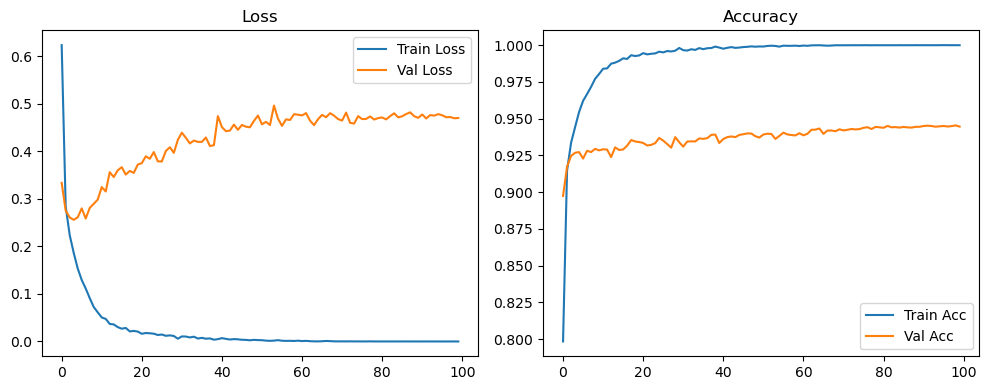

Evaluation:   0%|                                                                                                                                                                                                                | 0/7 [00:00<?, ?it/s]

Evaluation:  14%|████████████████████████████▌                                                                                                                                                                           | 1/7 [00:01<00:11,  1.87s/it]

Evaluation:  29%|█████████████████████████████████████████████████████████▏                                                                                                                                              | 2/7 [00:02<00:04,  1.13it/s]

Evaluation:  43%|█████████████████████████████████████████████████████████████████████████████████████▋                                                                                                                  | 3/7 [00:02<00:02,  1.77it/s]

Evaluation:  57%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                                                                     | 4/7 [00:02<00:01,  2.41it/s]

...

| LR: 0.000001 | Train Acc: 0.9999 | Val Acc: 0.9483 | Epoch Time: 0.27 | :  99%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋ | 99/100 [27:15<00:16, 16.01s/it]

| LR: 0.000001 | Train Acc: 0.9998 | Val Acc: 0.9480 | Epoch Time: 0.27 | :  99%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋ | 99/100 [27:31<00:16, 16.01s/it]

| LR: 0.000001 | Train Acc: 0.9998 | Val Acc: 0.9480 | Epoch Time: 0.27 | :  99%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋ | 99/100 [27:31<00:16, 16.01s/it]

| LR: 0.000001 | Train Acc: 0.9998 | Val Acc: 0.9480 | Epoch Time: 0.27 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [27:31<00:00, 16.01s/it]

| LR: 0.000001 | Train Acc: 0.9998 | Val Acc: 0.9480 | Epoch Time: 0.27 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [27:31<00:00, 16.52s/it]

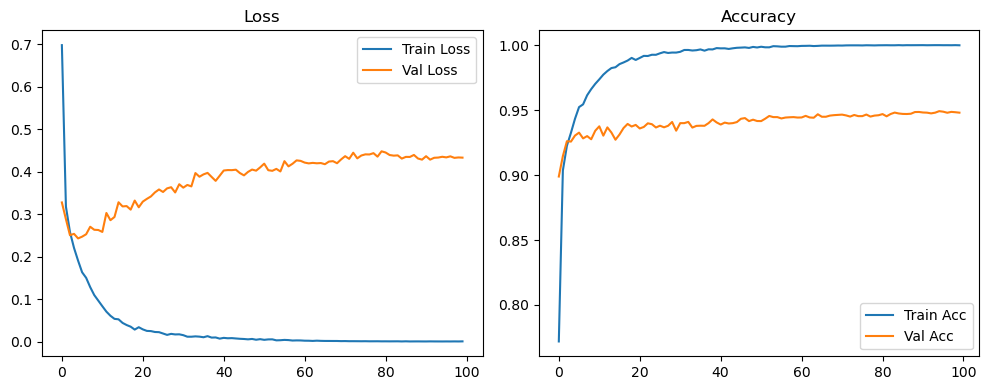

Evaluation:   0%|                                                                                                                                                                                                                | 0/7 [00:00<?, ?it/s]

Evaluation:  14%|████████████████████████████▌                                                                                                                                                                           | 1/7 [00:01<00:11,  1.88s/it]

Evaluation:  29%|█████████████████████████████████████████████████████████▏                                                                                                                                              | 2/7 [00:02<00:04,  1.13it/s]

Evaluation:  43%|█████████████████████████████████████████████████████████████████████████████████████▋                                                                                                                  | 3/7 [00:02<00:02,  1.76it/s]

Evaluation:  57%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                                                                     | 4/7 [00:02<00:01,  2.40it/s]

...

| LR: 0.000001 | Train Acc: 0.9998 | Val Acc: 0.9491 | Epoch Time: 0.26 | :  99%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋ | 99/100 [27:10<00:15, 15.86s/it]

| LR: 0.000001 | Train Acc: 0.9998 | Val Acc: 0.9485 | Epoch Time: 0.27 | :  99%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋ | 99/100 [27:26<00:15, 15.86s/it]

| LR: 0.000001 | Train Acc: 0.9998 | Val Acc: 0.9485 | Epoch Time: 0.27 | :  99%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋ | 99/100 [27:26<00:15, 15.86s/it]

| LR: 0.000001 | Train Acc: 0.9998 | Val Acc: 0.9485 | Epoch Time: 0.27 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [27:26<00:00, 15.91s/it]

| LR: 0.000001 | Train Acc: 0.9998 | Val Acc: 0.9485 | Epoch Time: 0.27 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [27:26<00:00, 16.46s/it]

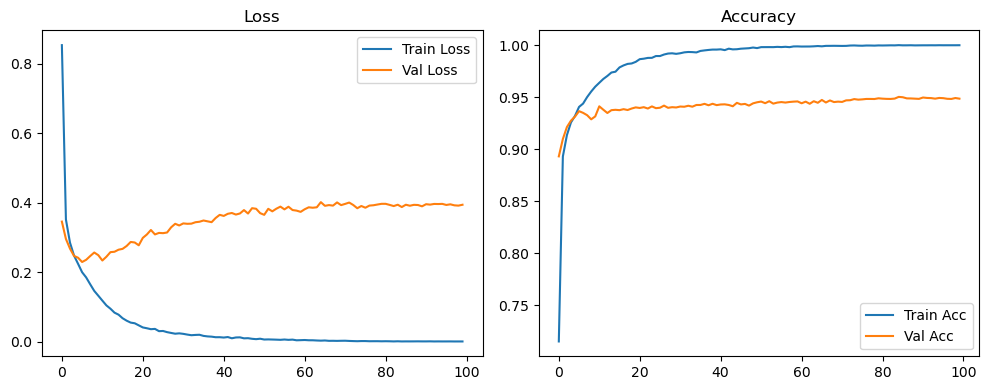

Evaluation:   0%|                                                                                                                                                                                                                | 0/7 [00:00<?, ?it/s]

Evaluation:  14%|████████████████████████████▌                                                                                                                                                                           | 1/7 [00:01<00:11,  1.87s/it]

Evaluation:  29%|█████████████████████████████████████████████████████████▏                                                                                                                                              | 2/7 [00:02<00:04,  1.14it/s]

Evaluation:  43%|█████████████████████████████████████████████████████████████████████████████████████▋                                                                                                                  | 3/7 [00:02<00:02,  1.78it/s]

Evaluation:  57%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                                                                     | 4/7 [00:02<00:01,  2.41it/s]

Evaluation:  71%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊                                                         | 5/7 [00:02<00:00,  3.00it/s]

Evaluation:  86%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                            | 6/7 [00:02<00:00,  3.51it/s]

Evaluation: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:02<00:00,  2.43it/s]

Original Model Final Test Loss: 0.3565 Accuracy: 0.9507




In [21]:
best_epochs, best_batch_size, best_lr_max, best_lr_min, best_dropout, best_resume_path  = Hyperparameter_searching(epochs, batch_sizes, lr_max_pool, lr_min_pool, dropout_rates)

In [22]:
best_evaluation(best_epochs, best_batch_size, best_lr_max, best_lr_min, best_dropout, best_resume_path)

Using downloaded and verified file: /home/yuhao/project/QModels-Brevitas-Example/brevitas_std_qnn/classification/SVHN/perChannel/dataset/SVHN/train_32x32.mat


Using downloaded and verified file: /home/yuhao/project/QModels-Brevitas-Example/brevitas_std_qnn/classification/SVHN/perChannel/dataset/SVHN/test_32x32.mat


Best model loaded.


Evaluation:   0%|                                                                                                                                                                                                                | 0/7 [00:00<?, ?it/s]

Evaluation:  14%|████████████████████████████▌                                                                                                                                                                           | 1/7 [00:01<00:10,  1.82s/it]

...

Evaluation:  57%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                                                                     | 4/7 [00:02<00:01,  2.46it/s]

Evaluation:  71%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊                                                         | 5/7 [00:02<00:00,  3.05it/s]

Evaluation:  86%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                            | 6/7 [00:02<00:00,  3.56it/s]

Evaluation: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:02<00:00,  2.48it/s]

Best Original Model Final Test Loss: 0.3656 Acc: 0.9507 


